# RetailPulse AI Retail Analytics

## Notebook 4 : Customer Segmentation using RFM + K-Means

### Objectives

- Load RFM Dataset
- Scale Features
- Find Optimal K
- Train KMeans Model
- Create Customer Segments
- Visualize Clusters
- Generate Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [2]:
rfm = pd.read_csv("../data/rfm_data.csv")

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [3]:
rfm = pd.read_csv("../data/rfm_data.csv")

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [6]:
rfm.isnull().sum()
scaler = StandardScaler()

scaled_data = scaler.fit_transform(rfm[["Recency","Frequency","Monetary"]])
scaled_data[:5]

array([[ 0.59558355,  0.43899789,  5.16637792],
       [-0.95227909,  0.13150188,  0.13612722],
       [-0.60353226, -0.09912012, -0.06485654],
       [-0.87106408, -0.17599412,  0.10199614],
       [ 0.51914589, -0.40661612, -0.18154933]])

In [8]:
#ELBOW METHOD
wcss = []

for i in range(1,11):

    model = KMeans(n_clusters=i,
                   random_state=42)

    model.fit(scaled_data)

    wcss.append(model.inertia_)

"The Elbow Method helps determine the optimal number of clusters by plotting the Within Cluster Sum of Squares (WCSS) against the number of clusters. The point where the decrease in WCSS starts slowing down resembles an elbow, indicating the best number of clusters."

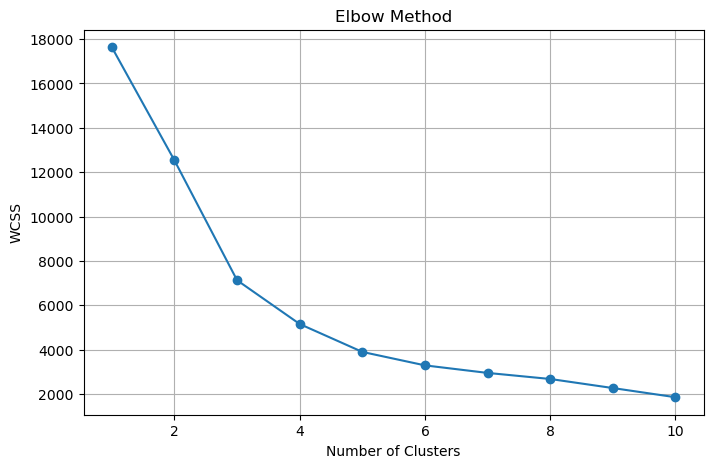

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(scaled_data)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346,326,12,77556.46,1
1,12347,2,8,4921.53,1
2,12348,75,5,2019.40,1
3,12349,19,4,4428.69,1
4,12350,310,1,334.40,0


In [11]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    2003
1    3836
2      35
3       4
Name: count, dtype: int64

In [12]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,462.52,2.21,749.23
1,66.76,7.31,2948.95
2,25.94,103.71,81356.34
3,3.50,212.50,428612.00


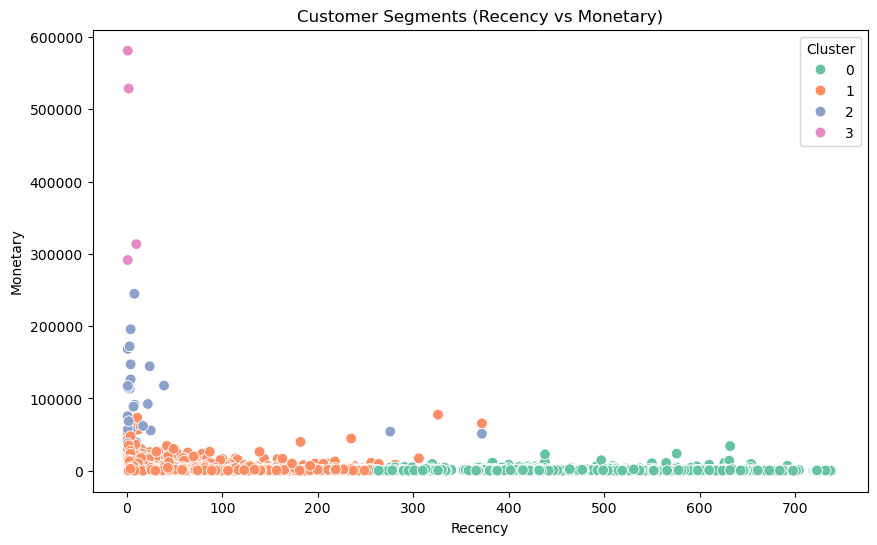

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("Customer Segments (Recency vs Monetary)")
plt.show()

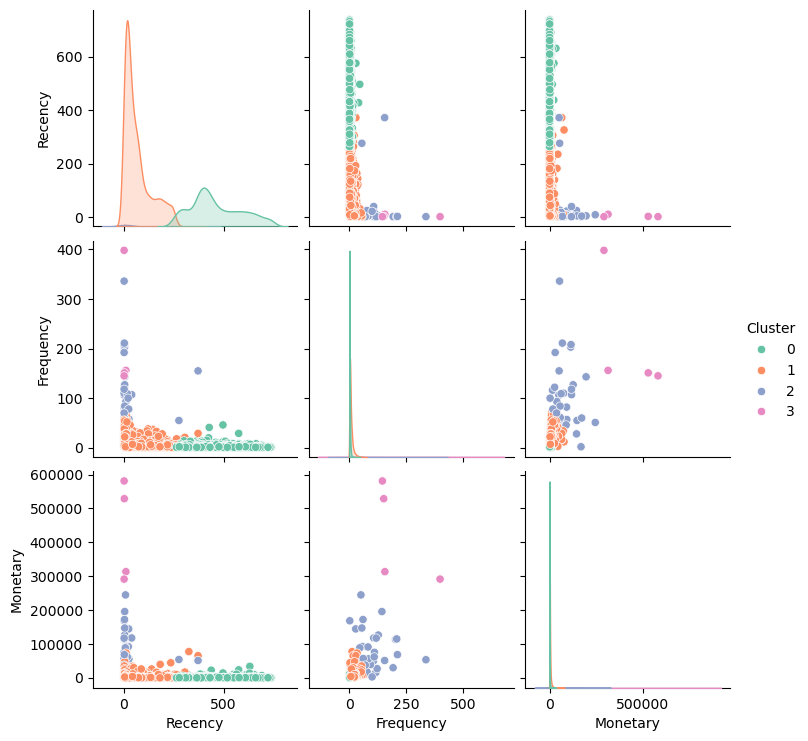

In [14]:
sns.pairplot(
    rfm,
    vars=["Recency", "Frequency", "Monetary"],
    hue="Cluster",
    palette="Set2"
)

plt.show()

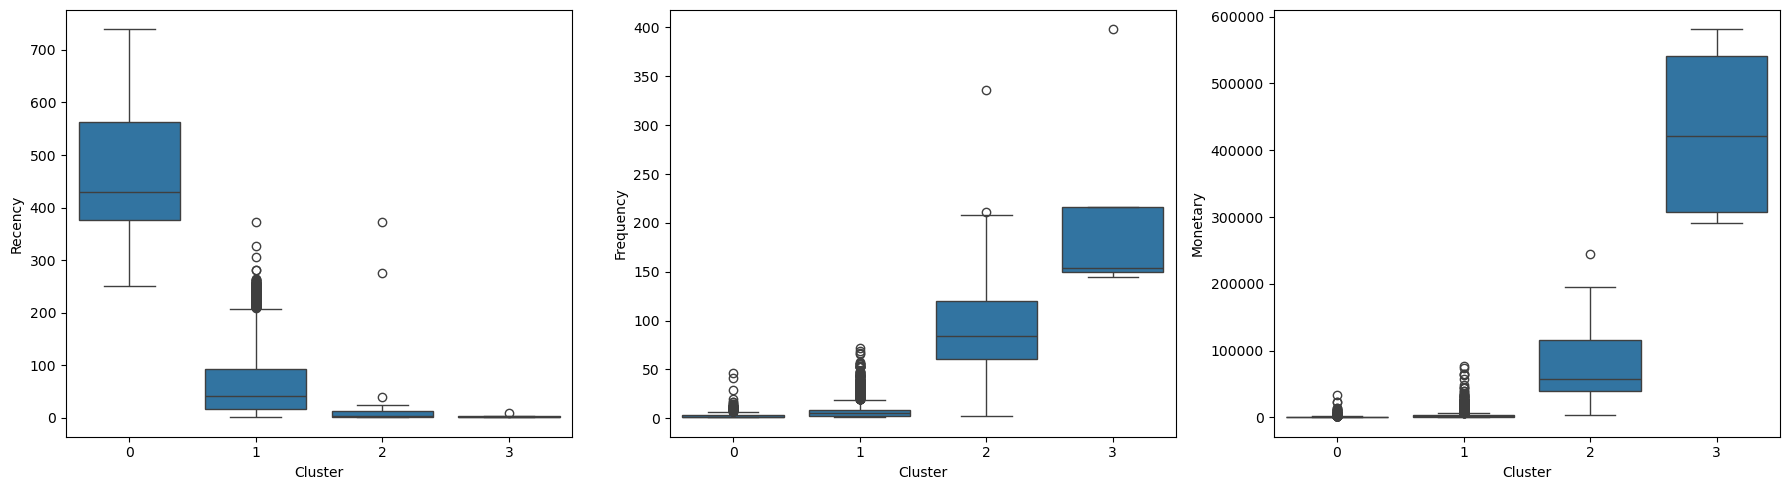

In [15]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(data=rfm, x="Cluster", y="Recency", ax=axes[0])

sns.boxplot(data=rfm, x="Cluster", y="Frequency", ax=axes[1])

sns.boxplot(data=rfm, x="Cluster", y="Monetary", ax=axes[2])

plt.tight_layout()

plt.show()

In [16]:
cluster_names = {
    0: "At Risk Customers",
    1: "Regular Customers",
    2: "Loyal Customers",
    3: "VIP Customers"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,12346,326,12,77556.46,1,Regular Customers
1,12347,2,8,4921.53,1,Regular Customers
2,12348,75,5,2019.40,1,Regular Customers
3,12349,19,4,4428.69,1,Regular Customers
4,12350,310,1,334.40,0,At Risk Customers


In [17]:
rfm["Customer_Segment"].value_counts()

Customer_Segment
Regular Customers    3836
At Risk Customers    2003
Loyal Customers        35
VIP Customers           4
Name: count, dtype: int64

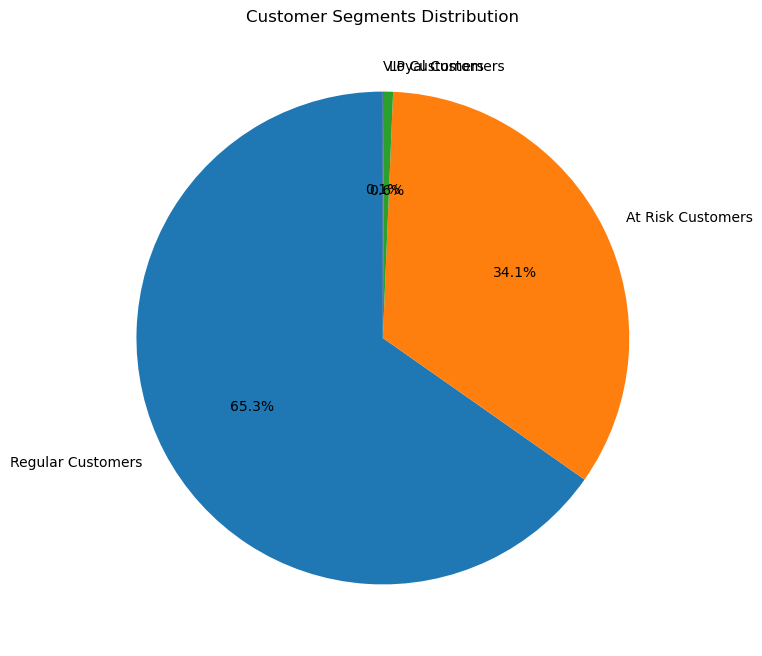

In [18]:
plt.figure(figsize=(8,8))

rfm["Customer_Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segments Distribution")
plt.ylabel("")

plt.show()

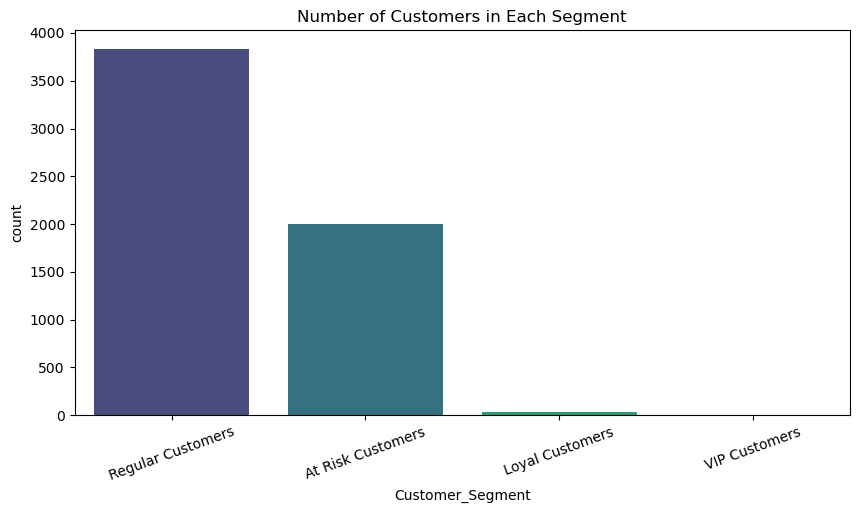

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x="Customer_Segment",
    order=rfm["Customer_Segment"].value_counts().index,
    palette="viridis"
)

plt.title("Number of Customers in Each Segment")

plt.xticks(rotation=20)

plt.show()

In [20]:
rfm.to_csv("../data/customer_segments.csv", index=False)

# Business Insights

 VIP Customers
- Highest spending customers
- Purchase very frequently
- Should receive exclusive rewards and premium membership

### 💎 Loyal Customers
- Frequent buyers with high revenue contribution
- Target with loyalty programs and personalized offers

### 🙂 Regular Customers
- Moderate purchase frequency
- Encourage repeat purchases through promotions and discounts

### 😴 At Risk Customers
- Have not purchased for a long time
- Launch win-back campaigns with special discounts and reminder emails